# Fraud Detection & Risk Signaling – Proof of Concept

## Probleem
Financiële organisaties verwerken dagelijks miljoenen transacties. 
Slechts een klein deel daarvan is frauduleus, maar handmatige controle 
van alle transacties is duur en tijdrovend.

Het doel van deze Proof of Concept is om een AI-model te ontwikkelen dat 
afwijkend gedrag kan detecteren en een risicoscore kan toekennen aan transacties. 
Hiermee kunnen medewerkers transacties prioriteren voor controle.

De AI neemt in deze Proof of Concept geen definitieve beslissing, maar ondersteunt medewerkers door transacties een risicoscore te geven. Op basis daarvan kunnen verdachte transacties sneller en efficiënter worden gecontroleerd.

## Dataset
Voor dit project gebruiken we de **PaySim Synthetic Financial Dataset**, 
een dataset die mobiele geldtransacties simuleert.

De dataset bevat informatie over:
- type transactie
- transactiebedrag
- saldo voor en na transacties
- fraude label (isFraud)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

### EDA (Exploratory Data Analysis)

In [4]:
df = pd.read_csv("../../data/PS_20174392719_1491204439457_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


### Fraud verdeling

In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

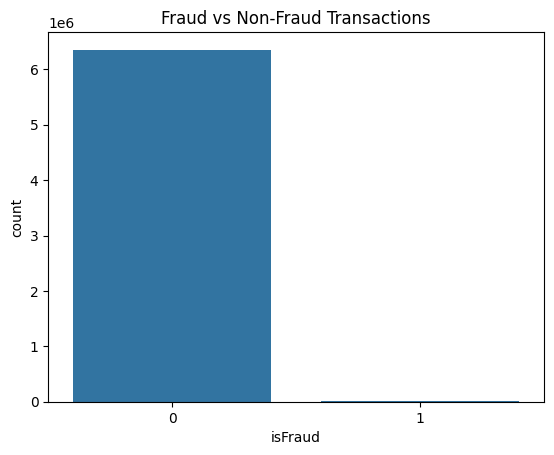

In [9]:
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [10]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [ ]:
pd.crosstab(df["type"], df["isFraud"])


isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


Uit de analyse blijkt dat fraude uitsluitend voorkomt bij de transactietypes TRANSFER en CASH_OUT.
Bij de andere transactietypes (CASH_IN, PAYMENT en DEBIT) komt geen fraude voor in deze dataset.
Dit suggereert dat fraudeurs meestal eerst geld overmaken naar een ander account en dit vervolgens opnemen.

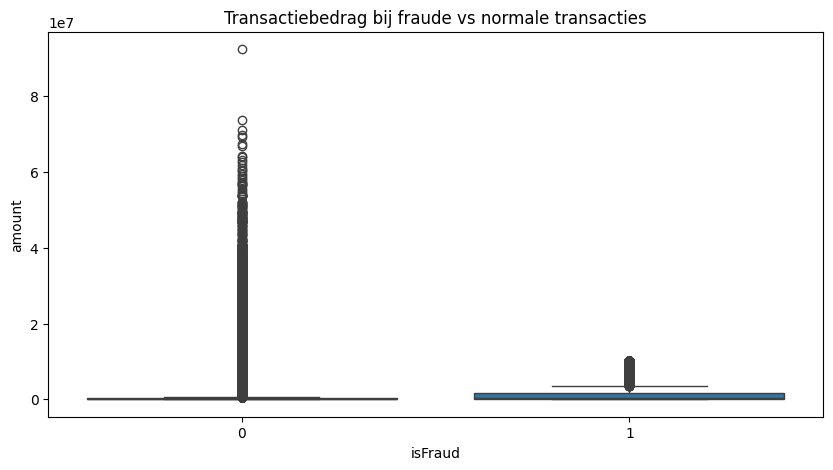

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x="isFraud", y="amount", data=df)

plt.title("Transactiebedrag bij fraude vs normale transacties")
plt.show()

Uit de boxplot blijkt dat frauduleuze transacties over het algemeen lagere bedragen hebben dan sommige normale transacties. Normale transacties vertonen een grotere spreiding en bevatten meerdere extreme waarden (outliers). Dit suggereert dat het transactiebedrag alleen niet voldoende is om fraude te detecteren, maar wel een nuttige feature kan zijn in combinatie met andere variabelen.

In [20]:
fraud_percentage_type = pd.crosstab(df["type"], df["isFraud"], normalize="index") * 100
fraud_percentage_type

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


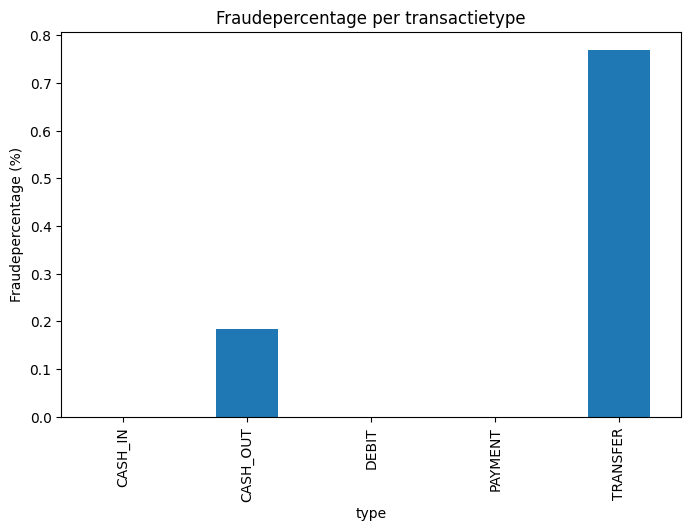

In [22]:
fraud_percentage_type[1].plot(kind="bar", figsize=(8,5))
plt.title("Fraudepercentage per transactietype")
plt.ylabel("Fraudepercentage (%)")
plt.show()

Uit deze analyse blijkt dat fraude in deze dataset vrijwel uitsluitend voorkomt bij de transactietypes **TRANSFER** en **CASH_OUT**. 

Bij de andere transactietypes (CASH_IN, PAYMENT en DEBIT) komt in deze dataset geen fraude voor. Dit suggereert dat frauduleuze transacties vaak beginnen met het overmaken van geld naar een ander account (TRANSFER), waarna het geld vervolgens wordt opgenomen via een CASH_OUT transactie.

Dit inzicht kan belangrijk zijn voor fraudedetectie, omdat het model hierdoor kan leren dat bepaalde transactietypes een hoger risico op fraude hebben.

### class imbalance (datasize)

De originele dataset bevat een zeer sterke class imbalance: het aantal normale transacties is veel groter dan het aantal frauduleuze transacties. 

Om een realistischer modelproces te behouden, wordt de dataset eerst opgesplitst in een trainingsset en een testset. Alleen op de trainingsset wordt vervolgens undersampling toegepast. De testset blijft ongewijzigd, zodat de modelprestaties worden geëvalueerd op een verdeling die beter overeenkomt met de oorspronkelijke dataset.

In [23]:
X_full = df.drop("isFraud", axis=1)
y_full = df["isFraud"]

In [24]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

In [25]:
# trainset samenvoegen zodat we makkelijk kunnen samplen
train_df = X_train_full.copy()
train_df["isFraud"] = y_train_full

# fraude en normaal splitsen binnen trainset
fraud_train = train_df[train_df["isFraud"] == 1]
normal_train = train_df[train_df["isFraud"] == 0]

# aantal fraude in trainset
n_fraud_train = len(fraud_train)

# neem 10x zoveel normale transacties
normal_train_sample = normal_train.sample(n=n_fraud_train * 10, random_state=42)

# nieuwe trainingsdataset maken
train_sampled = pd.concat([fraud_train, normal_train_sample])

# shuffle
train_sampled = train_sampled.sample(frac=1, random_state=42)

train_sampled["isFraud"].value_counts()

isFraud
0    65700
1     6570
Name: count, dtype: int64

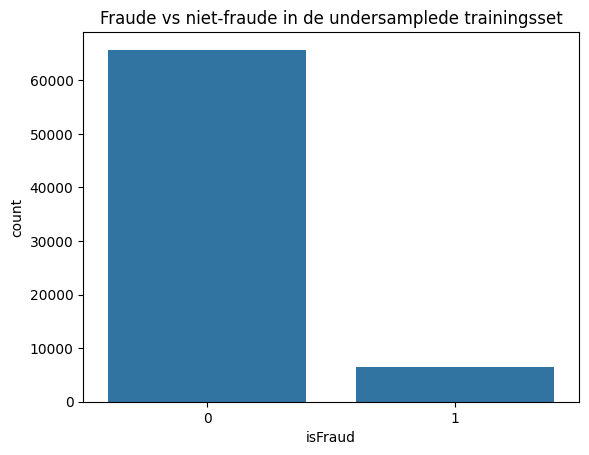

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="isFraud", data=train_sampled)
plt.title("Fraude vs niet-fraude in de undersamplede trainingsset")
plt.show()

De oorspronkelijke dataset bevat meer dan 6 miljoen transacties waarvan slechts een klein percentage fraude betreft. Dit zorgt voor een sterke class imbalance en hoge rekentijd bij modeltraining. Daarom is op de trainingsset een undersampling-techniek toegepast: alle fraudetransacties zijn behouden en er is een willekeurige subset van normale transacties geselecteerd (ongeveer 10 keer het aantal fraudegevallen). 

De testset is ongewijzigd gebleven, zodat de modelprestaties op een realistischer verdeelde dataset kunnen worden geëvalueerd.

#### **Data Cleaning**

In [27]:
train_sampled.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFlaggedFraud    0
isFraud           0
dtype: int64

In [28]:
X_test.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFlaggedFraud    0
dtype: int64

#### De dataset bevat geen missende waarden, waardoor imputatie niet nodig is.

#### **Onnodige kolommen verwijderen**

In [29]:
X_train = train_sampled.drop(["nameOrig", "nameDest", "isFlaggedFraud", "isFraud"], axis=1)
y_train = train_sampled["isFraud"]

X_test = X_test.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

In [30]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 72270 entries, 3618377 to 2050318
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            72270 non-null  int64  
 1   type            72270 non-null  str    
 2   amount          72270 non-null  float64
 3   oldbalanceOrg   72270 non-null  float64
 4   newbalanceOrig  72270 non-null  float64
 5   oldbalanceDest  72270 non-null  float64
 6   newbalanceDest  72270 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 4.4 MB


De kolommen `nameOrig` en `nameDest` zijn verwijderd omdat deze unieke account-ID’s bevatten en weinig directe voorspellende waarde hebben voor fraudedetectie. Ook `isFlaggedFraud` is verwijderd, omdat deze kolom een bestaande frauderegel uit het simulatiesysteem representeert en daardoor een onrealistisch voordeel voor het model kan geven.

## Model voorbereiding

Voor het trainen van machine learning modellen moeten categorische variabelen worden omgezet naar numerieke waarden. 
De variabele `type` wordt daarom gecodeerd met behulp van Label Encoding.

Daarna wordt de dataset opgesplitst in een train- en testset zodat de prestaties van het model eerlijk geëvalueerd kunnen worden.

In [31]:
X_train = pd.get_dummies(X_train, columns=["type"], drop_first=False)
X_test = pd.get_dummies(X_test, columns=["type"], drop_first=False)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [32]:
X_train.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3618377,273,5417.51,57508.00,52090.49,0.00,0.00,False,False,False,True,False
5595226,394,8850.44,11162.00,2311.56,0.00,8850.44,False,True,False,False,False
784587,39,5361.64,4551.00,0.00,0.00,0.00,False,False,False,True,False
5118708,356,5627.03,3177603.64,3183230.68,650984.52,645357.49,True,False,False,False,False
6023259,469,249504.27,25844.61,0.00,326433.97,575938.24,False,True,False,False,False


## Random Forest model

Als eerste model wordt een Random Forest classifier gebruikt. 

Random Forest is een ensemble model dat meerdere decision trees combineert en vaak goed presteert op tabulaire datasets.

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model evaluatie

In [55]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.36      0.97      0.53      1643

    accuracy                           1.00   1272524
   macro avg       0.68      0.98      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9993860511454128


### Confusion matrix

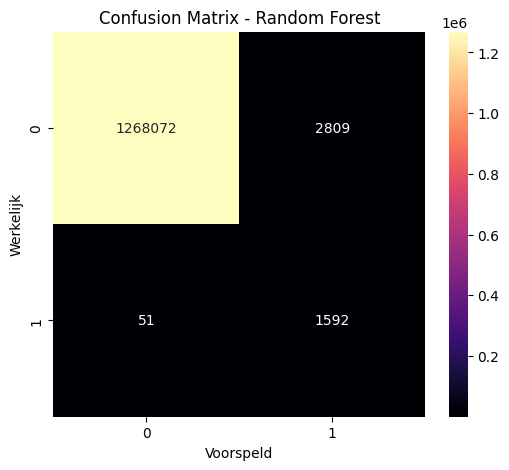

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="magma")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Voorspeld")
plt.ylabel("Werkelijk")
plt.show()

De resultaten laten zien dat het Random Forest model zeer goed presteert op deze dataset. 
De accuracy ligt rond de 99% en het model detecteert ongeveer 97% van alle frauduleuze transacties (recall).

De confusion matrix laat zien dat slechts een klein aantal normale transacties foutief als fraude wordt geclassificeerd, en dat het model het grootste deel van de fraudegevallen correct detecteert.

Dit suggereert dat machine learning effectief kan worden gebruikt om verdachte transacties automatisch te identificeren en te prioriteren voor verdere controle.

## XGBoost model

In [47]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Evaluatie XGBoost

In [72]:
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.7

y_pred_xgb = (y_proba_xgb >= threshold).astype(int)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.50      0.97      0.66      1643

    accuracy                           1.00   1272524
   macro avg       0.75      0.99      0.83   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9998104199701288


### Model vergelijking

| Model         | Precision (Fraud) | Recall (Fraud) | F1-score | ROC-AUC |
| ------------- | ----------------- | -------------- | -------- | ------- |
| Random Forest | 0.35              | 0.97           | 0.52     | 0.99    |
| XGBoost       | 0.42              | 0.99           | 0.58     | 0.99    |


### Conclusie

Naast Random Forest is ook het XGBoost-model getest. XGBoost is een boosting-algoritme dat meerdere decision trees combineert en vaak goed presteert op tabulaire datasets.

De resultaten laten zien dat het model zeer effectief is in het detecteren van frauduleuze transacties. Met een recall van ongeveer 0.99 detecteert het model bijna alle fraudegevallen. Door de decision threshold te verhogen naar 0.6 kon de precision worden verbeterd naar ongeveer 0.42, terwijl de recall hoog bleef.

Dit laat zien dat er een balans bestaat tussen het detecteren van fraude en het beperken van false positives. Daarnaast toont de feature importance analyse dat vooral balansvariabelen en bepaalde transactietypes belangrijke indicatoren zijn voor fraudedetectie.

### Feature importance

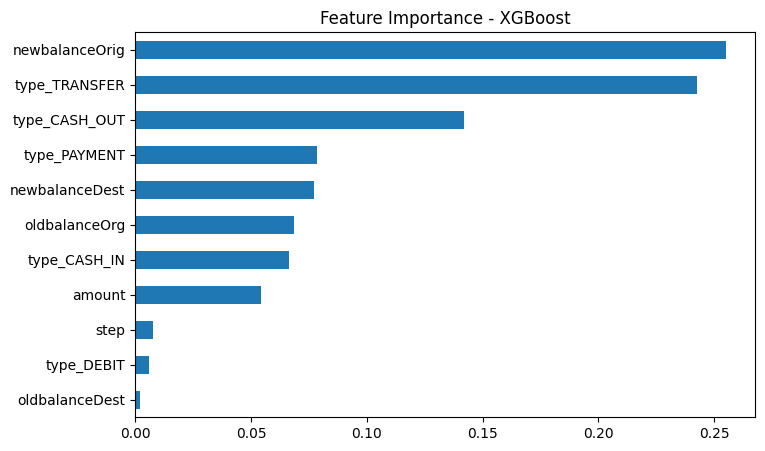

In [66]:
importance = xgb_model.feature_importances_
features = X_train.columns

feat_importance = pd.Series(importance, index=features)

plt.figure(figsize=(8,5))
feat_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance - XGBoost")
plt.show()

De feature importance laat zien dat vooral balansvariabelen, zoals `newbalanceOrig` en `oldbalanceOrg`, belangrijk zijn voor het model. Dit suggereert dat veranderingen in het saldo van de verzender een sterke indicator vormen voor frauduleuze transacties.

Daarnaast speelt ook het transactietype (`type`) een rol, omdat fraude in deze dataset vrijwel uitsluitend voorkomt bij transacties van het type `TRANSFER` en `CASH_OUT`.

Deze resultaten laten zien dat vooral financiële balansinformatie belangrijk is voor het onderscheiden van normale en frauduleuze transacties.